# Neural Network with Two Layers

Welcome to your week three programming assignment. You are ready to build a neural network with two layers and train it to solve a classification problem. 

**After this assignment, you will be able to:**

- Implement a neural network with two layers to a classification problem
- Implement forward propagation using matrix multiplication
- Perform backward propagation

# Table of Contents

- [ 1 - Classification Problem](#1)
- [ 2 - Neural Network Model with Two Layers](#2)
  - [ 2.1 - Neural Network Model with Two Layers for a Single Training Example](#2.1)
  - [ 2.2 - Neural Network Model with Two Layers for Multiple Training Examples](#2.2)
  - [ 2.3 - Cost Function and Training](#2.3)
  - [ 2.4 - Dataset](#2.4)
  - [ 2.5 - Define Activation Function](#2.5)
    - [ Exercise 1](#ex01)
- [ 3 - Implementation of the Neural Network Model with Two Layers](#3)
  - [ 3.1 - Defining the Neural Network Structure](#3.1)
    - [ Exercise 2](#ex02)
  - [ 3.2 - Initialize the Model's Parameters](#3.2)
    - [ Exercise 3](#ex03)
  - [ 3.3 - The Loop](#3.3)
    - [ Exercise 4](#ex04)
    - [ Exercise 5](#ex05)
    - [ Exercise 6](#ex06)
  - [ 3.4 - Integrate parts 3.1, 3.2 and 3.3 in nn_model()](#3.4)
    - [ Exercise 7](#ex07)
    - [ Exercise 8](#ex08)
- [ 4 - Optional: Other Dataset](#4)

## Packages

First, import all the packages you will need during this assignment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
# A function to create a dataset.
from sklearn.datasets import make_blobs

# Output of plotting commands is displayed inline within the Jupyter notebook.
%matplotlib inline 

# Set a seed so that the results are consistent.
np.random.seed(3)

Load the unit tests defined for this notebook.

In [2]:
import w3_unittest

<a name='1'></a>
## 1 - Classification Problem

In one of the labs this week, you trained a neural network with a single perceptron, performing forward and backward propagation. That simple structure was enough to solve a "linear" classification problem - finding a straight line in a plane that would serve as a decision boundary to separate two classes.

Imagine that now you have a more complicated problem: you still have two classes, but one line will not be enough to separate them.

[]

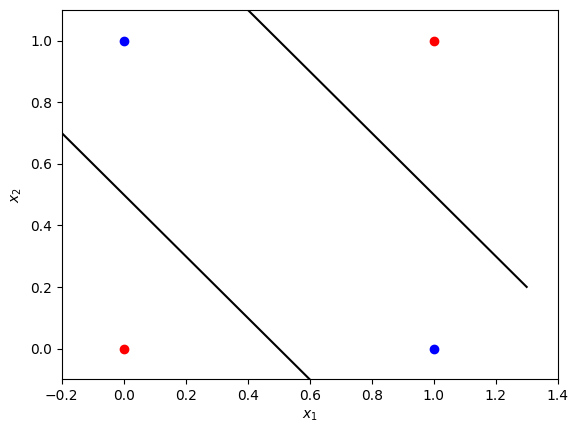

In [3]:
fig, ax = plt.subplots()
xmin, xmax = -0.2, 1.4
x_line = np.arange(xmin, xmax, 0.1)
# Data points (observations) from two classes.
ax.scatter(0, 0, color="r")
ax.scatter(0, 1, color="b")
ax.scatter(1, 0, color="b")
ax.scatter(1, 1, color="r")
ax.set_xlim([xmin, xmax])
ax.set_ylim([-0.1, 1.1])
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
# Example of the lines which can be used as a decision boundary to separate two classes.
ax.plot(x_line, -1 * x_line + 1.5, color="black")
ax.plot(x_line, -1 * x_line + 0.5, color="black")
plt.plot()

This logic can appear in many applications. For example, if you train a model to predict whether you should buy a house knowing its size and the year it was built. A big new house will not be affordable, while a small old house will not be worth buying. So, you might be interested in either a big old house, or a small new house.

The one perceptron neural network is not enough to solve such classification problem. Let's look at how you can adjust that model to find the solution.

In the plot above, two lines can serve as a decision boundary. Your intuition might tell you that you should also increase the number of perceptrons. And that is absolutely right! You need to feed your data points (coordinates $x_1$, $x_2$) into two nodes separately and then unify them somehow with another one to make a decision. 

Now let's figure out the details, build and train your first multi-layer neural network!

<a name='2'></a>
## 2 - Neural Network Model with Two Layers

<a name='2.1'></a>
### 2.1 - Neural Network Model with Two Layers for a Single Training Example

<img src="images/nn_model_2_layers.png" style="width:1000px;">

The input and output layers of the neural network are the same as for one perceptron model, but there is a **hidden layer** now in between them. The training examples $x^{(i)}=\begin{bmatrix}x_1^{(i)} \\ x_2^{(i)}\end{bmatrix}$ from the input layer of size $n_x = 2$ are first fed into the hidden layer of size $n_h = 2$. They are simultaneously fed into the first perceptron with weights $W_1^{[1]}=\begin{bmatrix}w_{1,1}^{[1]} & w_{2,1}^{[1]}\end{bmatrix}$, bias  $b_1^{[1]}$; and into the second perceptron with weights $W_2^{[1]}=\begin{bmatrix}w_{1,2}^{[1]} & w_{2,2}^{[1]}\end{bmatrix}$, bias $b_2^{[1]}$. The integer in the square brackets $^{[1]}$ denotes the layer number, because there are two layers now with their own parameters and outputs, which need to be distinguished. 

\begin{align}
z_1^{[1](i)} &= w_{1,1}^{[1]} x_1^{(i)} + w_{2,1}^{[1]} x_2^{(i)} + b_1^{[1]} = W_1^{[1]}x^{(i)} + b_1^{[1]},\\
z_2^{[1](i)} &= w_{1,2}^{[1]} x_1^{(i)} + w_{2,2}^{[1]} x_2^{(i)} + b_2^{[1]} = W_2^{[1]}x^{(i)} + b_2^{[1]}.\tag{1}
\end{align}

These expressions for one training example $x^{(i)}$ can be rewritten in a matrix form :

$$z^{[1](i)} = W^{[1]} x^{(i)} + b^{[1]},\tag{2}$$

where 

&emsp; &emsp; $z^{[1](i)} = \begin{bmatrix}z_1^{[1](i)} \\ z_2^{[1](i)}\end{bmatrix}$ is vector of size $\left(n_h \times 1\right) = \left(2 \times 1\right)$; 

&emsp; &emsp; $W^{[1]} = \begin{bmatrix}W_1^{[1]} \\ W_2^{[1]}\end{bmatrix} = 
\begin{bmatrix}w_{1,1}^{[1]} & w_{2,1}^{[1]} \\ w_{1,2}^{[1]} & w_{2,2}^{[1]}\end{bmatrix}$ is matrix of size $\left(n_h \times n_x\right) = \left(2 \times 2\right)$;

&emsp; &emsp; $b^{[1]} = \begin{bmatrix}b_1^{[1]} \\ b_2^{[1]}\end{bmatrix}$ is vector of size $\left(n_h \times 1\right) = \left(2 \times 1\right)$.

Next, the hidden layer activation function needs to be applied for each of the elements in the vector $z^{[1](i)}$. Various activation functions can be used here and in this model you will take the sigmoid function $\sigma\left(x\right) = \frac{1}{1 + e^{-x}}$. Remember that its derivative is $\frac{d\sigma}{dx} = \sigma\left(x\right)\left(1-\sigma\left(x\right)\right)$. The output of the hidden layer is a vector of size $\left(n_h \times 1\right) = \left(2 \times 1\right)$:

$$a^{[1](i)} = \sigma\left(z^{[1](i)}\right) = 
\begin{bmatrix}\sigma\left(z_1^{[1](i)}\right) \\ \sigma\left(z_2^{[1](i)}\right)\end{bmatrix}.\tag{3}$$

Then the hidden layer output gets fed into the output layer of size $n_y = 1$. This was covered in the previous lab, the only difference are: $a^{[1](i)}$ is taken instead of $x^{(i)}$ and layer notation $^{[2]}$ appears to identify all parameters and outputs:

$$z^{[2](i)} = w_1^{[2]} a_1^{[1](i)} + w_2^{[2]} a_2^{[1](i)} + b^{[2]}= W^{[2]} a^{[1](i)} + b^{[2]},\tag{4}$$

&emsp; &emsp; $z^{[2](i)}$ and $b^{[2]}$ are scalars for this model, as $\left(n_y \times 1\right) = \left(1 \times 1\right)$; 

&emsp; &emsp; $W^{[2]} = \begin{bmatrix}w_1^{[2]} & w_2^{[2]}\end{bmatrix}$ is vector of size $\left(n_y \times n_h\right) = \left(1 \times 2\right)$.

Finally, the same sigmoid function is used as the output layer activation function:

$$a^{[2](i)} = \sigma\left(z^{[2](i)}\right).\tag{5}$$

Mathematically the two layer neural network model for each training example $x^{(i)}$ can be written with the expressions $(2) - (5)$. Let's rewrite them next to each other for convenience:

\begin{align}
z^{[1](i)} &= W^{[1]} x^{(i)} + b^{[1]},\\
a^{[1](i)} &= \sigma\left(z^{[1](i)}\right),\\
z^{[2](i)} &= W^{[2]} a^{[1](i)} + b^{[2]},\\
a^{[2](i)} &= \sigma\left(z^{[2](i)}\right).\\
\tag{6}
\end{align}

Note, that all of the parameters to be trained in the model are without $^{(i)}$ index - they are independent on the input data.

Finally, the predictions for some example $x^{(i)}$ can be made taking the output $a^{[2](i)}$ and calculating $\hat{y}$ as: $\hat{y} = \begin{cases} 1 & \mbox{if } a^{[2](i)} > 0.5, \\ 0 & \mbox{otherwise }. \end{cases}$.

<a name='2.2'></a>
### 2.2 - Neural Network Model with Two Layers for Multiple Training Examples

Similarly to the single perceptron model, $m$ training examples can be organised in a matrix $X$ of a shape ($2 \times m$), putting $x^{(i)}$ into columns. Then the model $(6)$ can be rewritten in terms of matrix multiplications:

\begin{align}
Z^{[1]} &= W^{[1]} X + b^{[1]},\\
A^{[1]} &= \sigma\left(Z^{[1]}\right),\\
Z^{[2]} &= W^{[2]} A^{[1]} + b^{[2]},\\
A^{[2]} &= \sigma\left(Z^{[2]}\right),\\
\tag{7}
\end{align}

where $b^{[1]}$ is broadcasted to the matrix of size $\left(n_h \times m\right) = \left(2 \times m\right)$ and $b^{[2]}$ to the vector of size $\left(n_y \times m\right) = \left(1 \times m\right)$. It would be a good exercise for you to have a look at the expressions $(7)$ and check that sizes of the matrices will actually match to perform required multiplications.

You have derived expressions to perform forward propagation. Time to evaluate your model and train it.

<a name='2.3'></a>
### 2.3 - Cost Function and Training

For the evaluation of this simple neural network you can use the same cost function as for the single perceptron case - log loss function. Originally initialized weights were just some random values, now you need to perform training of the model: find such set of parameters $W^{[1]}$, $b^{[1]}$, $W^{[2]}$, $b^{[2]}$, that will minimize the cost function.

Like in the previous example of a single perceptron neural network, the cost function can be written as:

$$\mathcal{L}\left(W^{[1]}, b^{[1]}, W^{[2]}, b^{[2]}\right) = \frac{1}{m}\sum_{i=1}^{m} L\left(W^{[1]}, b^{[1]}, W^{[2]}, b^{[2]}\right) =  \frac{1}{m}\sum_{i=1}^{m}  \large\left(\small - y^{(i)}\log\left(a^{[2](i)}\right) - (1-y^{(i)})\log\left(1- a^{[2](i)}\right)  \large  \right), \small\tag{8}$$

where $y^{(i)} \in \{0,1\}$ are the original labels and $a^{[2](i)}$ are the continuous output values of the forward propagation step (elements of array $A^{[2]}$).

To minimize it, you can use gradient descent, updating the parameters with the following expressions:

\begin{align}
W^{[1]} &= W^{[1]} - \alpha \frac{\partial \mathcal{L} }{ \partial W^{[1]} },\\
b^{[1]} &= b^{[1]} - \alpha \frac{\partial \mathcal{L} }{ \partial b^{[1]} },\\
W^{[2]} &= W^{[2]} - \alpha \frac{\partial \mathcal{L} }{ \partial W^{[2]} },\\
b^{[2]} &= b^{[2]} - \alpha \frac{\partial \mathcal{L} }{ \partial b^{[2]} },\\
\tag{9}
\end{align}

where $\alpha$ is the learning rate.


To perform training of the model you need to calculate now $\frac{\partial \mathcal{L} }{ \partial W^{[1]}}$, $\frac{\partial \mathcal{L} }{ \partial b^{[1]}}$, $\frac{\partial \mathcal{L} }{ \partial W^{[2]}}$, $\frac{\partial \mathcal{L} }{ \partial b^{[2]}}$. 

Let's start from the end of the neural network. You can rewrite here the corresponding expressions for $\frac{\partial \mathcal{L} }{ \partial W }$ and $\frac{\partial \mathcal{L} }{ \partial b }$ from the single perceptron neural network:

\begin{align}
\frac{\partial \mathcal{L} }{ \partial W } &= 
\frac{1}{m}\left(A-Y\right)X^T,\\
\frac{\partial \mathcal{L} }{ \partial b } &= 
\frac{1}{m}\left(A-Y\right)\mathbf{1},\\
\end{align}

where $\mathbf{1}$ is just a ($m \times 1$) vector of ones. Your one perceptron is in the second layer now, so $W$ will be exchanged with $W^{[2]}$, $b$ with $b^{[2]}$, $A$ with $A^{[2]}$, $X$ with $A^{[1]}$:

\begin{align}
\frac{\partial \mathcal{L} }{ \partial W^{[2]} } &= 
\frac{1}{m}\left(A^{[2]}-Y\right)\left(A^{[1]}\right)^T,\\
\frac{\partial \mathcal{L} }{ \partial b^{[2]} } &= 
\frac{1}{m}\left(A^{[2]}-Y\right)\mathbf{1}.\\
\tag{10}
\end{align}


Let's now find $\frac{\partial \mathcal{L} }{ \partial W^{[1]}} = 
\begin{bmatrix}
\frac{\partial \mathcal{L} }{ \partial w_{1,1}^{[1]}} & \frac{\partial \mathcal{L} }{ \partial w_{2,1}^{[1]}} \\
\frac{\partial \mathcal{L} }{ \partial w_{1,2}^{[1]}} & \frac{\partial \mathcal{L} }{ \partial w_{2,2}^{[1]}} \end{bmatrix}$. It was shown in the videos that $$\frac{\partial \mathcal{L} }{ \partial w_{1,1}^{[1]}}=\frac{1}{m}\sum_{i=1}^{m} \left( 
\left(a^{[2](i)} - y^{(i)}\right) 
w_1^{[2]} 
\left(a_1^{[1](i)}\left(1-a_1^{[1](i)}\right)\right)
x_1^{(i)}\right)\tag{11}$$

If you do this accurately for each of the elements $\frac{\partial \mathcal{L} }{ \partial W^{[1]}}$, you will get the following matrix:

$$\frac{\partial \mathcal{L} }{ \partial W^{[1]}} = \begin{bmatrix}
\frac{\partial \mathcal{L} }{ \partial w_{1,1}^{[1]}} & \frac{\partial \mathcal{L} }{ \partial w_{2,1}^{[1]}} \\
\frac{\partial \mathcal{L} }{ \partial w_{1,2}^{[1]}} & \frac{\partial \mathcal{L} }{ \partial w_{2,2}^{[1]}} \end{bmatrix}$$
$$= \frac{1}{m}\begin{bmatrix}
\sum_{i=1}^{m} \left( \left(a^{[2](i)} - y^{(i)}\right) w_1^{[2]} \left(a_1^{[1](i)}\left(1-a_1^{[1](i)}\right)\right)
x_1^{(i)}\right) & 
\sum_{i=1}^{m} \left( \left(a^{[2](i)} - y^{(i)}\right) w_1^{[2]} \left(a_1^{[1](i)}\left(1-a_1^{[1](i)}\right)\right)
x_2^{(i)}\right)  \\
\sum_{i=1}^{m} \left( \left(a^{[2](i)} - y^{(i)}\right) w_2^{[2]} \left(a_2^{[1](i)}\left(1-a_2^{[1](i)}\right)\right)
x_1^{(i)}\right) & 
\sum_{i=1}^{m} \left( \left(a^{[2](i)} - y^{(i)}\right) w_2^{[2]} \left(a_2^{[1](i)}\left(1-a_2^{[1](i)}\right)\right)
x_2^{(i)}\right)\end{bmatrix}\tag{12}$$

Looking at this, you can notice that all terms and indices somehow are very consistent, so it all can be unified into a matrix form. And that's true! $\left(W^{[2]}\right)^T = \begin{bmatrix}w_1^{[2]} \\ w_2^{[2]}\end{bmatrix}$ of size $\left(n_h \times n_y\right) = \left(2 \times 1\right)$ can be multiplied with the vector $A^{[2]} - Y$ of size $\left(n_y \times m\right) = \left(1 \times m\right)$, resulting in a matrix of size $\left(n_h \times m\right) = \left(2 \times m\right)$:

$$\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)=
\begin{bmatrix}w_1^{[2]} \\ w_2^{[2]}\end{bmatrix}
\begin{bmatrix}\left(a^{[2](1)} - y^{(1)}\right) &  \cdots & \left(a^{[2](m)} - y^{(m)}\right)\end{bmatrix}
=\begin{bmatrix}
\left(a^{[2](1)} - y^{(1)}\right) w_1^{[2]} & \cdots & \left(a^{[2](m)} - y^{(m)}\right) w_1^{[2]} \\
\left(a^{[2](1)} - y^{(1)}\right) w_2^{[2]} & \cdots & \left(a^{[2](m)} - y^{(m)}\right) w_2^{[2]} \end{bmatrix}$$.

Now taking matrix $A^{[1]}$ of the same size $\left(n_h \times m\right) = \left(2 \times m\right)$,

$$A^{[1]}
=\begin{bmatrix}
a_1^{[1](1)} & \cdots & a_1^{[1](m)} \\
a_2^{[1](1)} & \cdots & a_2^{[1](m)} \end{bmatrix},$$

you can calculate:

$$A^{[1]}\cdot\left(1-A^{[1]}\right)
=\begin{bmatrix}
a_1^{[1](1)}\left(1 - a_1^{[1](1)}\right) & \cdots & a_1^{[1](m)}\left(1 - a_1^{[1](m)}\right) \\
a_2^{[1](1)}\left(1 - a_2^{[1](1)}\right) & \cdots & a_2^{[1](m)}\left(1 - a_2^{[1](m)}\right) \end{bmatrix},$$

where "$\cdot$" denotes **element by element** multiplication.

With the element by element multiplication,

$$\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)=\begin{bmatrix}
\left(a^{[2](1)} - y^{(1)}\right) w_1^{[2]}\left(a_1^{[1](1)}\left(1 - a_1^{[1](1)}\right)\right) & \cdots & \left(a^{[2](m)} - y^{(m)}\right) w_1^{[2]}\left(a_1^{[1](m)}\left(1 - a_1^{[1](m)}\right)\right) \\
\left(a^{[2](1)} - y^{(1)}\right) w_2^{[2]}\left(a_2^{[1](1)}\left(1 - a_2^{[1](1)}\right)\right) & \cdots & \left(a^{[2](m)} - y^{(m)}\right) w_2^{[2]} \left(a_2^{[1](m)}\left(1 - a_2^{[1](m)}\right)\right) \end{bmatrix}.$$

If you perform matrix multiplication with $X^T$ of size $\left(m \times n_x\right) = \left(m \times 2\right)$, you will get matrix of size $\left(n_h \times n_x\right) = \left(2 \times 2\right)$:

$$\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)X^T = 
\begin{bmatrix}
\left(a^{[2](1)} - y^{(1)}\right) w_1^{[2]}\left(a_1^{[1](1)}\left(1 - a_1^{[1](1)}\right)\right) & \cdots & \left(a^{[2](m)} - y^{(m)}\right) w_1^{[2]}\left(a_1^{[1](m)}\left(1 - a_1^{[1](m)}\right)\right) \\
\left(a^{[2](1)} - y^{(1)}\right) w_2^{[2]}\left(a_2^{[1](1)}\left(1 - a_2^{[1](1)}\right)\right) & \cdots & \left(a^{[2](m)} - y^{(m)}\right) w_2^{[2]} \left(a_2^{[1](m)}\left(1 - a_2^{[1](m)}\right)\right) \end{bmatrix}
\begin{bmatrix}
x_1^{(1)} & x_2^{(1)} \\
\cdots & \cdots \\
x_1^{(m)} & x_2^{(m)}
\end{bmatrix}$$
$$=\begin{bmatrix}
\sum_{i=1}^{m} \left( \left(a^{[2](i)} - y^{(i)}\right) w_1^{[2]} \left(a_1^{[1](i)}\left(1 - a_1^{[1](i)}\right) \right)
x_1^{(i)}\right) & 
\sum_{i=1}^{m} \left( \left(a^{[2](i)} - y^{(i)}\right) w_1^{[2]} \left(a_1^{[1](i)}\left(1-a_1^{[1](i)}\right)\right)
x_2^{(i)}\right)  \\
\sum_{i=1}^{m} \left( \left(a^{[2](i)} - y^{(i)}\right) w_2^{[2]} \left(a_2^{[1](i)}\left(1-a_2^{[1](i)}\right)\right)
x_1^{(i)}\right) & 
\sum_{i=1}^{m} \left( \left(a^{[2](i)} - y^{(i)}\right) w_2^{[2]} \left(a_2^{[1](i)}\left(1-a_2^{[1](i)}\right)\right)
x_2^{(i)}\right)\end{bmatrix}$$

This is exactly like in the expression $(12)$! So, $\frac{\partial \mathcal{L} }{ \partial W^{[1]}}$ can be written as a mixture of multiplications:

$$\frac{\partial \mathcal{L} }{ \partial W^{[1]}} = \frac{1}{m}\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)X^T\tag{13},$$

where "$\cdot$" denotes element by element multiplications.

Vector $\frac{\partial \mathcal{L} }{ \partial b^{[1]}}$ can be found very similarly, but the last terms in the chain rule will be equal to $1$, i.e. $\frac{\partial z_1^{[1](i)}}{ \partial b_1^{[1]}} = 1$. Thus,

$$\frac{\partial \mathcal{L} }{ \partial b^{[1]}} = \frac{1}{m}\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)\mathbf{1},\tag{14}$$

where $\mathbf{1}$ is a ($m \times 1$) vector of ones.

Expressions $(10)$, $(13)$ and $(14)$ can be used for the parameters update $(9)$ performing backward propagation:

\begin{align}
\frac{\partial \mathcal{L} }{ \partial W^{[2]} } &= 
\frac{1}{m}\left(A^{[2]}-Y\right)\left(A^{[1]}\right)^T,\\
\frac{\partial \mathcal{L} }{ \partial b^{[2]} } &= 
\frac{1}{m}\left(A^{[2]}-Y\right)\mathbf{1},\\
\frac{\partial \mathcal{L} }{ \partial W^{[1]}} &= \frac{1}{m}\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)X^T,\\
\frac{\partial \mathcal{L} }{ \partial b^{[1]}} &= \frac{1}{m}\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)\mathbf{1},\\
\tag{15}
\end{align}

where $\mathbf{1}$ is a ($m \times 1$) vector of ones.

So, to understand deeply and properly how neural networks perform and get trained, **you do need knowledge of linear algebra and calculus joined together**! But do not worry! All together it is not that scary if you do it step by step accurately with understanding of maths.

Time to implement this all in the code!

<a name='2.2'></a>
### 2.2 - Dataset

First, let's get the dataset you will work on. The following code will create $m=2000$ data points $(x_1, x_2)$ and save them in the `NumPy` array `X` of a shape $(2 \times m)$ (in the columns of the array). The labels ($0$: blue, $1$: red) will be saved in the `NumPy` array `Y` of a shape $(1 \times m)$.

The shape of X is: (2, 2000)
The shape of Y is: (1, 2000)
I have m = 2000 training examples!


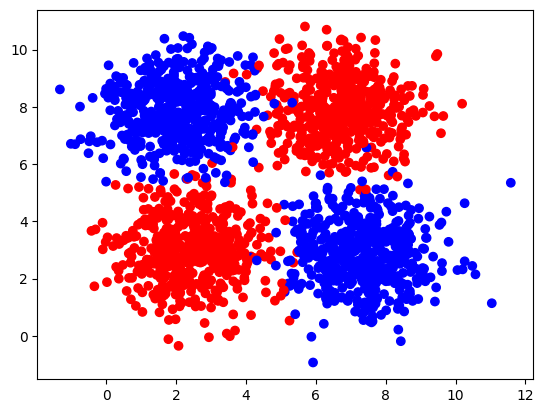

In [4]:
m = 2000
samples, labels = make_blobs(n_samples=m, 
                             centers=([2.5, 3], [6.7, 7.9], [2.1, 7.9], [7.4, 2.8]), 
                             cluster_std=1.1,
                             random_state=0)
labels[(labels == 0) | (labels == 1)] = 1
labels[(labels == 2) | (labels == 3)] = 0
X = np.transpose(samples)
Y = labels.reshape((1, m))

plt.scatter(X[0, :], X[1, :], c=Y, cmap=colors.ListedColormap(['blue', 'red']));

print ('The shape of X is: ' + str(X.shape))
print ('The shape of Y is: ' + str(Y.shape))
print ('I have m = %d training examples!' % (m))

<a name='2.3'></a>
### 2.3 - Define Activation Function

<a name='ex01'></a>
### Exercise 1

Define sigmoid activation function $\sigma\left(z\right) =\frac{1}{1+e^{-z}} $.

In [6]:
def sigmoid(z):
    ### START CODE HERE ### (~ 1 line of code)
    res = 1/(1 + np.exp(-z))
    ### END CODE HERE ###
    
    return res

In [7]:
print("sigmoid(-2) = " + str(sigmoid(-2)))
print("sigmoid(0) = " + str(sigmoid(0)))
print("sigmoid(3.5) = " + str(sigmoid(3.5)))

sigmoid(-2) = 0.11920292202211755
sigmoid(0) = 0.5
sigmoid(3.5) = 0.9706877692486436


##### __Expected Output__

Note: the values may vary in the last decimal places.

```Python
sigmoid(-2) = 0.11920292202211755
sigmoid(0) = 0.5
sigmoid(3.5) = 0.9706877692486436
```

In [8]:
w3_unittest.test_sigmoid(sigmoid)

 All tests passed


<a name='3'></a>
## 3 - Implementation of the Neural Network Model with Two Layers

<a name='3.1'></a>
### 3.1 - Defining the Neural Network Structure

<a name='ex02'></a>
### Exercise 2

Define three variables:
- `n_x`: the size of the input layer
- `n_h`: the size of the hidden layer (set it equal to 2 for now)
- `n_y`: the size of the output layer

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hint</b></font>
</summary>
<p>
<ul>
    Use shapes of X and Y to find n_x and n_y:
    <li>the size of the input layer n_x equals to the size of the input vectors placed in the columns of the array X,</li>
    <li>the outpus for each of the data point will be saved in the columns of the the array Y.</li>
</ul>
</p>

In [12]:
# GRADED FUNCTION: layer_sizes

def layer_sizes(X, Y):
    """
    Arguments:
    X -- input dataset of shape (input size, number of examples)
    Y -- labels of shape (output size, number of examples)
    
    Returns:
    n_x -- the size of the input layer
    n_h -- the size of the hidden layer
    n_y -- the size of the output layer
    """
    ### START CODE HERE ### (~ 3 lines of code)
    # Size of input layer.
    n_x = X.shape[0]
    # Size of hidden layer.
    n_h = 2
    # Size of output layer.
    n_y = Y.shape[0]
    ### END CODE HERE ###
    return (n_x, n_h, n_y)

In [13]:
(n_x, n_h, n_y) = layer_sizes(X, Y)
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))

The size of the input layer is: n_x = 2
The size of the hidden layer is: n_h = 2
The size of the output layer is: n_y = 1


##### __Expected Output__

```Python
The size of the input layer is: n_x = 2
The size of the hidden layer is: n_h = 2
The size of the output layer is: n_y = 1
```

In [14]:
w3_unittest.test_layer_sizes(layer_sizes)

 All tests passed


<a name='3.2'></a>
### 3.2 - Initialize the Model's Parameters

<a name='ex03'></a>
### Exercise 3

Implement the function `initialize_parameters()`.

**Instructions**:
- Make sure your parameters' sizes are right. Refer to the neural network figure above if needed.
- You will initialize the weights matrix with random values. 
    - Use: `np.random.randn(a,b) * 0.01` to randomly initialize a matrix of shape (a,b).
- You will initialize the bias vector as zeros. 
    - Use: `np.zeros((a,b))` to initialize a matrix of shape (a,b) with zeros.

In [15]:
# GRADED FUNCTION: initialize_parameters

def initialize_parameters(n_x, n_h, n_y):
    """
    Argument:
    n_x -- size of the input layer
    n_h -- size of the hidden layer
    n_y -- size of the output layer
    
    Returns:
    params -- python dictionary containing your parameters:
                    W1 -- weight matrix of shape (n_h, n_x)
                    b1 -- bias vector of shape (n_h, 1)
                    W2 -- weight matrix of shape (n_y, n_h)
                    b2 -- bias vector of shape (n_y, 1)
    """
    
    ### START CODE HERE ### (~ 4 lines of code)
    W1 = np.random.randn(n_h,n_x)*0.01
    b1 = np.zeros((n_h,1))
    W2 = np.random.randn(n_y,n_h)*0.01
    b2 = np.zeros((n_y,1))
    ### END CODE HERE ###
    
    assert (W1.shape == (n_h, n_x))
    assert (b1.shape == (n_h, 1))
    assert (W2.shape == (n_y, n_h))
    assert (b2.shape == (n_y, 1))
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [16]:
parameters = initialize_parameters(n_x, n_h, n_y)

print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[ 0.01788628  0.0043651 ]
 [ 0.00096497 -0.01863493]]
b1 = [[0.]
 [0.]]
W2 = [[-0.00277388 -0.00354759]]
b2 = [[0.]]


##### __Expected Output__ 
Note: the elements of the arrays W1 and W2 maybe be different due to random initialization. You can try to restart the kernel to get the same values.

```Python
W1 = [[ 0.01788628  0.0043651 ]
 [ 0.00096497 -0.01863493]]
b1 = [[0.]
 [0.]]
W2 = [[-0.00277388 -0.00354759]]
b2 = [[0.]]
```

In [17]:
# Note: 
# Actual values are not checked here in the unit tests (due to random initialization).
w3_unittest.test_initialize_parameters(initialize_parameters)

 All tests passed


<a name='3.3'></a>
### 3.3 - The Loop

<a name='ex04'></a>
### Exercise 4

Implement `forward_propagation()`.

**Instructions**:
- Look above at the mathematical representation $(7)$ of your classifier (section [2.2](#2.2)):
\begin{align}
Z^{[1]} &= W^{[1]} X + b^{[1]},\\
A^{[1]} &= \sigma\left(Z^{[1]}\right),\\
Z^{[2]} &= W^{[2]} A^{[1]} + b^{[2]},\\
A^{[2]} &= \sigma\left(Z^{[2]}\right).\\
\end{align}
- The steps you have to implement are:
    1. Retrieve each parameter from the dictionary "parameters" (which is the output of `initialize_parameters()`) by using `parameters[".."]`.
    2. Implement Forward Propagation. Compute `Z1` multiplying matrices `W1`, `X` and adding vector `b1`. Then find `A1` using the `sigmoid` activation function. Perform similar computations for `Z2` and `A2`.

In [18]:
# GRADED FUNCTION: forward_propagation

def forward_propagation(X, parameters):
    """
    Argument:
    X -- input data of size (n_x, m)
    parameters -- python dictionary containing your parameters (output of initialization function)
    
    Returns:
    A2 -- the sigmoid output of the second activation
    cache -- python dictionary containing Z1, A1, Z2, A2 
    (that simplifies the calculations in the back propagation step)
    """
    # Retrieve each parameter from the dictionary "parameters".
    ### START CODE HERE ### (~ 4 lines of code)
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    ### END CODE HERE ###
    
    # Implement forward propagation to calculate A2.
    ### START CODE HERE ### (~ 4 lines of code)
    Z1 = W1 @ X + b1
    A1 = sigmoid(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    ### END CODE HERE ###
    
    assert(A2.shape == (n_y, X.shape[1]))

    cache = {"Z1": Z1,
             "A1": A1,
             "Z2": Z2,
             "A2": A2}
    
    return A2, cache

In [19]:
A2, cache = forward_propagation(X, parameters)

print(A2)

[[0.49920157 0.49922234 0.49921223 ... 0.49921215 0.49921043 0.49920665]]


##### __Expected Output__ 
Note: the elements of the array A2 maybe be different depending on the initial parameters. If you would like to get exactly the same output, try to restart the Kernel and rerun the notebook.

```Python
[[0.49920157 0.49922234 0.49921223 ... 0.49921215 0.49921043 0.49920665]]
```

In [20]:
# Note: 
# Actual values are not checked here in the unit tests (due to random initialization).
w3_unittest.test_forward_propagation(forward_propagation)

 All tests passed


Remember, that your weights were just initialized with some random values, so the model has not been trained yet. 

<a name='ex05'></a>
### Exercise 5

Define a cost function $(8)$ which will be used to train the model:

$$\mathcal{L}\left(W, b\right)  = \frac{1}{m}\sum_{i=1}^{m}  \large\left(\small - y^{(i)}\log\left(a^{(i)}\right) - (1-y^{(i)})\log\left(1- a^{(i)}\right)  \large  \right) \small.$$

In [58]:
def compute_cost(A2, Y):
    """
    Computes the cost function as a log loss
    
    Arguments:
    A2 -- The output of the neural network of shape (1, number of examples)
    Y -- "true" labels vector of shape (1, number of examples)
    
    Returns:
    cost -- log loss
    
    """
    # Number of examples.
    m = Y.shape[1]
    
    ### START CODE HERE ### (~ 2 lines of code)
    logloss = (np.dot(-Y, np.log(A2).T)-np.dot((1-Y),np.log(1-A2).T)).squeeze().astype(float)
    cost = (1/m*logloss)
    print(cost)
    ### END CODE HERE ###
    

    assert(isinstance(cost, float))
    
    return cost

In [59]:
print("cost = " + str(compute_cost(A2, Y)))

0.6931477703826822
cost = 0.6931477703826822


##### __Expected Output__ 
Note: the elements of the arrays W1 and W2 maybe be different!

```Python
cost = 0.6931477703826823
```

In [60]:
# Note: 
# Actual values are not checked here in the unit tests (due to random initialization).
w3_unittest.test_compute_cost(compute_cost, A2)

0.6931477703826822
0.5901032749748385
 All tests passed


Calculate partial derivatives as shown in $(15)$:

\begin{align}
\frac{\partial \mathcal{L} }{ \partial W^{[2]} } &= 
\frac{1}{m}\left(A^{[2]}-Y\right)\left(A^{[1]}\right)^T,\\
\frac{\partial \mathcal{L} }{ \partial b^{[2]} } &= 
\frac{1}{m}\left(A^{[2]}-Y\right)\mathbf{1},\\
\frac{\partial \mathcal{L} }{ \partial W^{[1]}} &= \frac{1}{m}\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)X^T,\\
\frac{\partial \mathcal{L} }{ \partial b^{[1]}} &= \frac{1}{m}\left(\left(W^{[2]}\right)^T \left(A^{[2]} - Y\right)\cdot \left(A^{[1]}\cdot\left(1-A^{[1]}\right)\right)\right)\mathbf{1}.\\
\end{align}

In [61]:
def backward_propagation(parameters, cache, X, Y):
    """
    Implements the backward propagation, calculating gradients
    
    Arguments:
    parameters -- python dictionary containing our parameters 
    cache -- python dictionary containing Z1, A1, Z2, A2
    X -- input data of shape (n_x, number of examples)
    Y -- "true" labels vector of shape (n_y, number of examples)
    
    Returns:
    grads -- python dictionary containing gradients with respect to different parameters
    """
    m = X.shape[1]
    
    # First, retrieve W from the dictionary "parameters".
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    
    # Retrieve also A1 and A2 from dictionary "cache".
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    # Backward propagation: calculate partial derivatives denoted as dW1, db1, dW2, db2 for simplicity. 
    dZ2 = A2 - Y
    dW2 = 1/m * np.dot(dZ2, A1.T)
    db2 = 1/m * np.sum(dZ2, axis = 1, keepdims = True)
    dZ1 = np.dot(W2.T, dZ2) * A1 * (1 - A1)
    dW1 = 1/m * np.dot(dZ1, X.T)
    db1 = 1/m * np.sum(dZ1, axis = 1, keepdims = True)
    
    grads = {"dW1": dW1,
             "db1": db1,
             "dW2": dW2,
             "db2": db2}
    
    return grads

grads = backward_propagation(parameters, cache, X, Y)

print("dW1 = " + str(grads["dW1"]))
print("db1 = " + str(grads["db1"]))
print("dW2 = " + str(grads["dW2"]))
print("db2 = " + str(grads["db2"]))

dW1 = [[-1.49856632e-05  1.67791519e-05]
 [-2.12394543e-05  2.43895135e-05]]
db1 = [[5.11207671e-07]
 [7.06236219e-07]]
dW2 = [[-0.00032641 -0.0002606 ]]
db2 = [[-0.00078732]]


<a name='ex06'></a>
### Exercise 6

Implement `update_parameters()`.

**Instructions**:
- Update parameters as shown in $(9)$ (section [2.3](#2.3)):
\begin{align}
W^{[1]} &= W^{[1]} - \alpha \frac{\partial \mathcal{L} }{ \partial W^{[1]} },\\
b^{[1]} &= b^{[1]} - \alpha \frac{\partial \mathcal{L} }{ \partial b^{[1]} },\\
W^{[2]} &= W^{[2]} - \alpha \frac{\partial \mathcal{L} }{ \partial W^{[2]} },\\
b^{[2]} &= b^{[2]} - \alpha \frac{\partial \mathcal{L} }{ \partial b^{[2]} }.\\
\end{align}
- The steps you have to implement are:
    1. Retrieve each parameter from the dictionary "parameters" (which is the output of `initialize_parameters()`) by using `parameters[".."]`.
    2. Retrieve each derivative from the dictionary "grads" (which is the output of `backward_propagation()`) by using `grads[".."]`.
    3. Update parameters.

In [62]:
def update_parameters(parameters, grads, learning_rate=1.2):
    """
    Updates parameters using the gradient descent update rule
    
    Arguments:
    parameters -- python dictionary containing parameters 
    grads -- python dictionary containing gradients
    learning_rate -- learning rate for gradient descent
    
    Returns:
    parameters -- python dictionary containing updated parameters 
    """
    # Retrieve each parameter from the dictionary "parameters".
    ### START CODE HERE ### (~ 4 lines of code)
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    ### END CODE HERE ###
    
    # Retrieve each gradient from the dictionary "grads".
    ### START CODE HERE ### (~ 4 lines of code)
    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]
    ### END CODE HERE ###
    
    # Update rule for each parameter.
    ### START CODE HERE ### (~ 4 lines of code)
    W1 = W1 - learning_rate*dW1
    b1 = b1 - learning_rate*db1
    W2 = W2 - learning_rate*dW2
    b2 = b2 - learning_rate*db2
    ### END CODE HERE ###
    
    parameters = {"W1": W1,
                  "b1": b1,
                  "W2": W2,
                  "b2": b2}
    
    return parameters

In [63]:
parameters_updated = update_parameters(parameters, grads)

print("W1 updated = " + str(parameters_updated["W1"]))
print("b1 updated = " + str(parameters_updated["b1"]))
print("W2 updated = " + str(parameters_updated["W2"]))
print("b2 updated = " + str(parameters_updated["b2"]))

W1 updated = [[ 0.01790427  0.00434496]
 [ 0.00099046 -0.01866419]]
b1 updated = [[-6.13449205e-07]
 [-8.47483463e-07]]
W2 updated = [[-0.00238219 -0.00323487]]
b2 updated = [[0.00094478]]


##### __Expected Output__ 
Note: the actual values can be different!

```Python
W1 updated = [[ 0.01790427  0.00434496]
 [ 0.00099046 -0.01866419]]
b1 updated = [[-6.13449205e-07]
 [-8.47483463e-07]]
W2 updated = [[-0.00238219 -0.00323487]]
b2 updated = [[0.00094478]]
```

In [64]:
w3_unittest.test_update_parameters(update_parameters)

 All tests passed


<a name='3.4'></a>
### 3.4 - Integrate parts 3.1, 3.2 and 3.3 in nn_model()

<a name='ex07'></a>
### Exercise 7

Build your neural network model in `nn_model()`.

**Instructions**: The neural network model has to use the previous functions in the right order.

In [65]:
# GRADED FUNCTION: nn_model

def nn_model(X, Y, n_h, num_iterations=10, learning_rate=1.2, print_cost=False):
    """
    Arguments:
    X -- dataset of shape (n_x, number of examples)
    Y -- labels of shape (n_y, number of examples)
    num_iterations -- number of iterations in the loop
    learning_rate -- learning rate parameter for gradient descent
    print_cost -- if True, print the cost every iteration
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """
    
    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[2]
    
    # Initialize parameters.
    ### START CODE HERE ### (~ 1 line of code)
    parameters = initialize_parameters(n_x, n_h, n_y)
    ### END CODE HERE ###
    
    # Loop.
    for i in range(0, num_iterations):
         
        ### START CODE HERE ### (~ 4 lines of code)
        # Forward propagation. Inputs: "X, parameters". Outputs: "A2, cache".
        A2, cache = forward_propagation(X, parameters)
        
        # Cost function. Inputs: "A2, Y". Outputs: "cost".
        cost = compute_cost(A2, Y)
        
        # Backpropagation. Inputs: "parameters, cache, X, Y". Outputs: "grads".
        grads = backward_propagation(parameters, cache, X, Y)
        
        # Gradient descent parameter update. Inputs: "parameters, grads, learning_rate". Outputs: "parameters".
        parameters = update_parameters(parameters, grads, learning_rate)
        ### END CODE HERE ###
        
        # Print the cost every iteration.
        if print_cost:
            print ("Cost after iteration %i: %f" %(i, cost))

    return parameters

In [66]:
parameters = nn_model(X, Y, n_h=2, num_iterations=3000, learning_rate=1.2, print_cost=True)
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = parameters["W1"]
b1 = parameters["b1"]
W2 = parameters["W2"]
b2 = parameters["b2"]

0.6931660911234399
Cost after iteration 0: 0.693166
0.693152997274991
Cost after iteration 1: 0.693153
0.6931489168866829
Cost after iteration 2: 0.693149
0.6931476288103163
Cost after iteration 3: 0.693148
0.693147206368701
Cost after iteration 4: 0.693147
0.6931470523035921
Cost after iteration 5: 0.693147
0.6931469813788691
Cost after iteration 6: 0.693147
0.6931469361256215
Cost after iteration 7: 0.693147
0.6931468987062324
Cost after iteration 8: 0.693147
0.6931468635777814
Cost after iteration 9: 0.693147
0.6931468290117276
Cost after iteration 10: 0.693147
0.6931467944629124
Cost after iteration 11: 0.693147
0.6931467597532567
Cost after iteration 12: 0.693147
0.6931467248184832
Cost after iteration 13: 0.693147
0.6931466896295257
Cost after iteration 14: 0.693147
0.6931466541681394
Cost after iteration 15: 0.693147
0.6931466184193334
Cost after iteration 16: 0.693147
0.6931465823690105
Cost after iteration 17: 0.693147
0.6931465460032432
Cost after iteration 18: 0.693147
0.693

0.270904193795877
Cost after iteration 408: 0.270904
0.27003557831826003
Cost after iteration 409: 0.270036
0.26917736236069095
Cost after iteration 410: 0.269177
0.2683292628467199
Cost after iteration 411: 0.268329
0.2674910073713227
Cost after iteration 412: 0.267491
0.2666623338391595
Cost after iteration 413: 0.266662
0.26584299011797546
Cost after iteration 414: 0.265843
0.2650327337063703
Cost after iteration 415: 0.265033
0.26423133141519506
Cost after iteration 416: 0.264231
0.2634385590618578
Cost after iteration 417: 0.263439
0.26265420117686167
Cost after iteration 418: 0.262654
0.2618780507219092
Cost after iteration 419: 0.261878
0.26110990881894874
Cost after iteration 420: 0.261110
0.2603495844895515
Cost after iteration 421: 0.260350
0.2595968944040426
Cost after iteration 422: 0.259597
0.25885166263982534
Cost after iteration 423: 0.258852
0.25811372044836145
Cost after iteration 424: 0.258114
0.25738290603030123
Cost after iteration 425: 0.257383
0.2566590643182648
C

0.19979210710827955
Cost after iteration 843: 0.199792
0.2066094247439692
Cost after iteration 844: 0.206609
0.2255980159708767
Cost after iteration 845: 0.225598
0.24620174151852472
Cost after iteration 846: 0.246202
0.31908262764274054
Cost after iteration 847: 0.319083
0.37323812768827935
Cost after iteration 848: 0.373238
0.673669328010016
Cost after iteration 849: 0.673669
0.5474361004044805
Cost after iteration 850: 0.547436
0.7571783288458285
Cost after iteration 851: 0.757178
0.28588509162634934
Cost after iteration 852: 0.285885
0.23939815829352246
Cost after iteration 853: 0.239398
0.21129211358978012
Cost after iteration 854: 0.211292
0.20428247533978866
Cost after iteration 855: 0.204282
0.2017384336038311
Cost after iteration 856: 0.201738
0.2006462100571102
Cost after iteration 857: 0.200646
0.19994512121772368
Cost after iteration 858: 0.199945
0.19939747942214306
Cost after iteration 859: 0.199397
0.1989121653474822
Cost after iteration 860: 0.198912
0.19846261919459654

Cost after iteration 1173: 0.196987
0.196491243263782
Cost after iteration 1174: 0.196491
0.19602416074775045
Cost after iteration 1175: 0.196024
0.19558396547288534
Cost after iteration 1176: 0.195584
0.19516874767488407
Cost after iteration 1177: 0.195169
0.19477676644341846
Cost after iteration 1178: 0.194777
0.1944064299183981
Cost after iteration 1179: 0.194406
0.19405627840485085
Cost after iteration 1180: 0.194056
0.19372497003906272
Cost after iteration 1181: 0.193725
0.19341126847476522
Cost after iteration 1182: 0.193411
0.19311403228779705
Cost after iteration 1183: 0.193114
0.19283220578525403
Cost after iteration 1184: 0.192832
0.19256481100283368
Cost after iteration 1185: 0.192565
0.19231094069121463
Cost after iteration 1186: 0.192311
0.1920697521416871
Cost after iteration 1187: 0.192070
0.19184046171981686
Cost after iteration 1188: 0.191840
0.19162234000397985
Cost after iteration 1189: 0.191622
0.19141470744021666
Cost after iteration 1190: 0.191415
0.19121693044197

0.22966447255031375
Cost after iteration 1571: 0.229664
0.2080350917089139
Cost after iteration 1572: 0.208035
0.1991530708214065
Cost after iteration 1573: 0.199153
0.19545722215638836
Cost after iteration 1574: 0.195457
0.19401070535909118
Cost after iteration 1575: 0.194011
0.1933139747280451
Cost after iteration 1576: 0.193314
0.1928890657088366
Cost after iteration 1577: 0.192889
0.19256040145602538
Cost after iteration 1578: 0.192560
0.1922764455296
Cost after iteration 1579: 0.192276
0.19201688068144107
Cost after iteration 1580: 0.192017
0.19177427937525432
Cost after iteration 1581: 0.191774
0.19154521313912823
Cost after iteration 1582: 0.191545
0.19132791463472323
Cost after iteration 1583: 0.191328
0.1911213158850942
Cost after iteration 1584: 0.191121
0.19092461524278462
Cost after iteration 1585: 0.190925
0.19073718693863576
Cost after iteration 1586: 0.190737
0.19055846690688158
Cost after iteration 1587: 0.190558
0.19038796025240157
Cost after iteration 1588: 0.190388
0

Cost after iteration 2024: 0.190383
0.1902332115455651
Cost after iteration 2025: 0.190233
0.1900918382253764
Cost after iteration 2026: 0.190092
0.1899576675322141
Cost after iteration 2027: 0.189958
0.1898297525459477
Cost after iteration 2028: 0.189830
0.18970753720968345
Cost after iteration 2029: 0.189708
0.1895905573177267
Cost after iteration 2030: 0.189591
0.18947845610046118
Cost after iteration 2031: 0.189478
0.1893709292948506
Cost after iteration 2032: 0.189371
0.1892677062464892
Cost after iteration 2033: 0.189268
0.18916855024891685
Cost after iteration 2034: 0.189169
0.18907323774872567
Cost after iteration 2035: 0.189073
0.18898156936289093
Cost after iteration 2036: 0.188982
0.1888933529910426
Cost after iteration 2037: 0.188893
0.18880841497155307
Cost after iteration 2038: 0.188808
0.18872658716547933
Cost after iteration 2039: 0.188727
0.18864771617248802
Cost after iteration 2040: 0.188648
0.18857165348641047
Cost after iteration 2041: 0.188572
0.1884982627571823
C

0.18873433384018515
Cost after iteration 2462: 0.188734
0.18862139546259157
Cost after iteration 2463: 0.188621
0.1885068808083324
Cost after iteration 2464: 0.188507
0.18842207853263268
Cost after iteration 2465: 0.188422
0.18833384043411502
Cost after iteration 2466: 0.188334
0.1882650134857822
Cost after iteration 2467: 0.188265
0.18819253280576248
Cost after iteration 2468: 0.188193
0.1881341595226046
Cost after iteration 2469: 0.188134
0.18807224943759884
Cost after iteration 2470: 0.188072
0.18802167702483816
Cost after iteration 2471: 0.188022
0.1879676449047309
Cost after iteration 2472: 0.187968
0.18792365740700975
Cost after iteration 2473: 0.187924
0.18787613626962674
Cost after iteration 2474: 0.187876
0.18783841372049678
Cost after iteration 2475: 0.187838
0.18779688137474881
Cost after iteration 2476: 0.187797
0.18776586826315178
Cost after iteration 2477: 0.187766
0.18773050398363103
Cost after iteration 2478: 0.187731
0.18770755085417937
Cost after iteration 2479: 0.187

Cost after iteration 2905: 0.213473
0.20919085147863964
Cost after iteration 2906: 0.209191
0.2112375104575327
Cost after iteration 2907: 0.211238
0.2093030254927922
Cost after iteration 2908: 0.209303
0.21215104567010082
Cost after iteration 2909: 0.212151
0.2108334174169201
Cost after iteration 2910: 0.210833
0.2142919812883348
Cost after iteration 2911: 0.214292
0.2124641694178734
Cost after iteration 2912: 0.212464
0.21575575322802865
Cost after iteration 2913: 0.215756
0.21271912239427263
Cost after iteration 2914: 0.212719
0.21467315341084367
Cost after iteration 2915: 0.214673
0.21036527149309028
Cost after iteration 2916: 0.210365
0.21012360192263332
Cost after iteration 2917: 0.210124
0.2053526345744369
Cost after iteration 2918: 0.205353
0.20339296524598516
Cost after iteration 2919: 0.203393
0.1993896993509171
Cost after iteration 2920: 0.199390
0.19721646171339843
Cost after iteration 2921: 0.197216
0.1946253568964139
Cost after iteration 2922: 0.194625
0.19313101998598103


##### __Expected Output__ 
Note: the actual values can be different!

```Python
Cost after iteration 0: 0.693148
Cost after iteration 1: 0.693147
Cost after iteration 2: 0.693147
Cost after iteration 3: 0.693147
Cost after iteration 4: 0.693147
Cost after iteration 5: 0.693147
...
Cost after iteration 2995: 0.209524
Cost after iteration 2996: 0.208025
Cost after iteration 2997: 0.210427
Cost after iteration 2998: 0.208929
Cost after iteration 2999: 0.211306
W1 = [[ 2.14274251 -1.93155541]
 [ 2.20268789 -2.1131799 ]]
b1 = [[-4.83079243]
 [ 6.2845223 ]]
W2 = [[-7.21370685  7.0898022 ]]
b2 = [[-3.48755239]]
```

In [67]:
# Note: 
# Actual values are not checked here in the unit tests (due to random initialization).
w3_unittest.test_nn_model(nn_model)

0.6931477674434523
0.6931474096837485
0.6931472864684783
0.6931472301151489
0.6931471928248503
0.6931471609657471
0.6931471306439778
0.693147100741134
0.693147070929851
0.6931470411082177
0.6931470112385636
0.6931469813015193
0.6931469512829076
0.6931469211700062
0.6931468909504851
0.6931468606120894
0.6931468301425566
0.6931467995295796
0.6931467687608027
0.6931467378238085
0.6931467067061119
0.6931466753951617
0.6931466438783298
0.6931466121429085
0.6931465801761018
0.6931465479650318
0.6931465154967129
0.6931464827580707
0.6931464497359212
0.6931464164169703
0.6931463827878078
0.6931463488349027
0.6931463145445996
0.6931462799031102
0.6931462448965119
0.6931462095107384
0.6931461737315754
0.6931461375446578
0.6931461009354621
0.6931460638892977
0.6931460263913098
0.6931459884264635
0.6931459499795465
0.6931459110351553
0.6931458715776991
0.6931458315913842
0.6931457910602149
0.6931457499679821
0.6931457082982627
0.6931456660344076
0.6931456231595408
0.6931455796565453
0.693145535508

0.24509093718794586
0.23350713024812114
0.23163337819441152
0.22612113491237404
0.2247563852716704
0.2218433186057519
0.22075706248913474
0.21904527553553857
0.2181937221933495
0.21707469643383975
0.21639049517281564
0.21557869460772003
0.21500458596694505
0.21436084442852768
0.21385888619583107
0.2133133667805661
0.21286091670394877
0.21237764164001124
0.21196212723336547
0.21152241250129078
0.21113781760106695
0.21073254669979208
0.21037768893278797
0.2100039737679072
0.20968236089909126
0.2093428474856933
0.2090644058297804
0.20876913006335304
0.20855525652175333
0.20832786758970764
0.20822413091271993
0.20811863930846622
0.20822785250306589
0.20837545503019425
0.20895182445371013
0.2097063894190263
0.21145963969117787
0.21392624731387755
0.21919662033838372
0.22759264403947987
0.24623565844663564
0.27968077676402714
0.3701846724781797
0.46091320726925006
0.6604489485822042
0.3591669165256416
0.36050733694591847
0.2695431945949523
0.24820087092476878
0.22651593101452613
0.2208907174

0.18794026967891528
0.1878671519223756
0.1877960884035014
0.18772701215912582
0.18765986022835573
0.1875945795222736
0.18753111820007218
0.1874694446306349
0.18740952301536104
0.18735136113779022
0.1872949503989404
0.18724038087120476
0.18718769546608216
0.18713717226307625
0.18708895694871858
0.18704378793382265
0.18700201485515078
0.18696557463926106
0.186935185823317
0.1869161025669418
0.18690949620141944
0.18693041774928343
0.1869793527662607
0.187102405798813
0.1872907016272183
0.1876966797183684
0.18825486112057327
0.18951283011589892
0.19112010959957382
0.19520580495052756
0.20002086698019167
0.21412272211741784
0.22609625704979208
0.2709423591716231
0.27144647670709193
0.3647712000874457
0.331513536739786
0.5016550801700845
0.46491485519460984
0.5765936571907675
0.286312943217916
0.26166807196382313
0.22143904105355516
0.2066962856986021
0.19896197540125546
0.19601179726453358
0.19456653011055475
0.19387729688394548
0.1934186874277221
0.19308244551515424
0.1927963705216223
0.19

0.2471654040971708
0.2785861361163814
0.263990603290258
0.29237251315488094
0.2538549874490846
0.2558559916549966
0.2251205510625855
0.2136597290158789
0.20151238751759348
0.19599103608881974
0.1928331610968218
0.1915352655967758
0.19079778222057553
0.19041551435397028
0.19013452391456911
0.18993904480499033
0.1897693898351983
0.18962928264789494
0.18949990672485809
0.18938412473242958
0.18927466412318222
0.1891729843471884
0.18907582325639977
0.18898391695653044
0.18889560115299048
0.18881127174376247
0.18872996994508265
0.18865192920897872
0.18857652985318996
0.18850392705999225
0.18843367582072582
0.18836589657421077
0.18830023837097146
0.1882368129543237
0.18817531951859381
0.18811588071577706
0.1880582181103981
0.18800248514567067
0.18794840383497116
0.18789618492097626
0.18784552796595272
0.18779674337745528
0.1877494771135142
0.18770421454791011
0.1876604966565646
0.1876191272730357
0.1875794459136275
0.18754286407824378
0.18750832041310458
0.1874784483846033
0.18745133901311176

0.18762817430205223
0.18760463339168387
0.18759086700982852
0.187578389249589
0.18758293533424195
0.18758880554938123
0.18762664526703404
0.18766497027897536
0.18776756788699372
0.18786631391599823
0.1881029105768023
0.18831937362762113
0.18885108790725663
0.18930906817625426
0.19053654208941653
0.19152831813261662
0.19452235428768558
0.19678379550364247
0.2044877631815528
0.20903573006227824
0.22797284996373987
0.22767378721132725
0.2612452410797267
0.23633803647443657
0.2646555628956739
0.22615398284086577
0.23593134871338664
0.21457758698272603
0.21755905869880268
0.209128046251224
0.2106749494332692
0.20662924248971912
0.2080701174617325
0.20598522536347783
0.20779422962271696
0.20647434727266945
0.20863931931443253
0.20730635071084638
0.20949338632796013
0.20766559735380719
0.20935622777380883
0.20684494314742666
0.20753712193382423
0.20450712479673347
0.2040598592157224
0.20099777019763013
0.19982369029372202
0.19726090519652603
0.1959941154744743
0.19417029446807954
0.1931817377

0.18917876254383426
0.1893335735675634
0.18991989389519842
0.19019840910437888
0.19123513488666982
0.19173256632266775
0.19364848483981548
0.1945531716372073
0.198266160599191
0.1998715529897909
0.20722568812891057
0.20922752302916764
0.22276908963766423
0.2208569077108896
0.2401532498187962
0.227581978117362
0.24551035804055024
0.2279697897264057
0.2407766019211344
0.22866722568973927
0.2405194304303536
0.2349804953935252
0.25239772710345393
0.2500476586141527
0.2801955318650047
0.268710118778523
0.30291506989488104
0.26551199859626246
0.2757934349816938
0.23699743993653902
0.22635929249146639
0.2085904509001805
0.20096216927530458
0.19542566796470265
0.1933254022363818
0.19180178088142635
0.1911508065938593
0.19058813163608115
0.19028504842545835
0.19000888158440704
0.18982470213849978
0.18965490633290497
0.18952216089792423
0.18939817922477137
0.18929127014072641
0.18919013124014908
0.1890981267126624
0.1890102714858038
0.1889280903123772
0.18884914299069153
0.18877420200996212
0.18

The final model parameters can be used to find the boundary line and for making predictions. 

<a name='ex08'></a>
### Exercise 8

Computes probabilities using forward propagation, and make classification to 0/1 using 0.5 as the threshold.

In [70]:
# GRADED FUNCTION: predict

def predict(X, parameters):
    """
    Using the learned parameters, predicts a class for each example in X
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    X -- input data of size (n_x, m)
    
    Returns
    predictions -- vector of predictions of our model (blue: 0 / red: 1)
    """
    
    ### START CODE HERE ### (≈ 2 lines of code)
    A2, cache = forward_propagation(X, parameters)
    predictions = A2 > 0.5
    ### END CODE HERE ###
    
    return predictions

In [71]:
X_pred = np.array([[2, 8, 2, 8], [2, 8, 8, 2]])
Y_pred = predict(X_pred, parameters)

print(f"Coordinates (in the columns):\n{X_pred}")
print(f"Predictions:\n{Y_pred}")

Coordinates (in the columns):
[[2 8 2 8]
 [2 8 8 2]]
Predictions:
[[ True  True False False]]


##### __Expected Output__ 

```Python
Coordinates (in the columns):
[[2 8 2 8]
 [2 8 8 2]]
Predictions:
[[ True  True False False]]
```

In [72]:
w3_unittest.test_predict(predict)

 All tests passed


Let's visualize the boundary line. Do not worry if you don't understand the function `plot_decision_boundary` line by line - it simply makes prediction for some points on the plane and plots them as a contour plot (just two colors - blue and red).

Text(0.5, 1.0, 'Decision Boundary for hidden layer size 2')

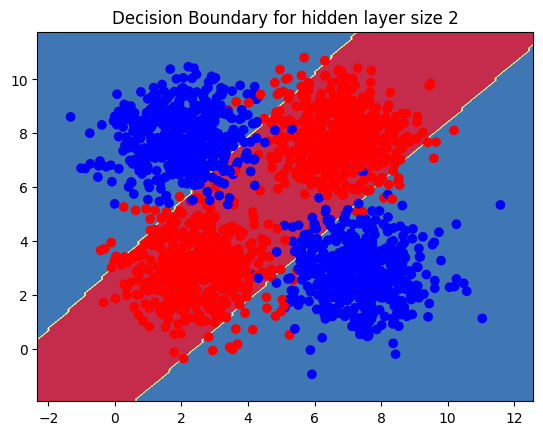

In [73]:
def plot_decision_boundary(predict, parameters, X, Y):
    # Define bounds of the domain.
    min1, max1 = X[0, :].min()-1, X[0, :].max()+1
    min2, max2 = X[1, :].min()-1, X[1, :].max()+1
    # Define the x and y scale.
    x1grid = np.arange(min1, max1, 0.1)
    x2grid = np.arange(min2, max2, 0.1)
    # Create all of the lines and rows of the grid.
    xx, yy = np.meshgrid(x1grid, x2grid)
    # Flatten each grid to a vector.
    r1, r2 = xx.flatten(), yy.flatten()
    r1, r2 = r1.reshape((1, len(r1))), r2.reshape((1, len(r2)))
    # Vertical stack vectors to create x1,x2 input for the model.
    grid = np.vstack((r1,r2))
    # Make predictions for the grid.
    predictions = predict(grid, parameters)
    # Reshape the predictions back into a grid.
    zz = predictions.reshape(xx.shape)
    # Plot the grid of x, y and z values as a surface.
    plt.contourf(xx, yy, zz, cmap=plt.cm.Spectral.reversed())
    plt.scatter(X[0, :], X[1, :], c=Y, cmap=colors.ListedColormap(['blue', 'red']));

# Plot the decision boundary.
plot_decision_boundary(predict, parameters, X, Y)
plt.title("Decision Boundary for hidden layer size " + str(n_h))

That's great, you can see that more complicated classification problems can be solved with two layer neural network!

<a name='4'></a>
## 4 - Optional: Other Dataset

Build a slightly different dataset:

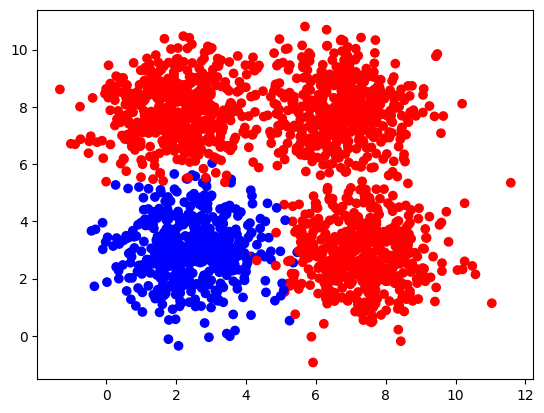

In [74]:
n_samples = 2000
samples, labels = make_blobs(n_samples=n_samples, 
                             centers=([2.5, 3], [6.7, 7.9], [2.1, 7.9], [7.4, 2.8]), 
                             cluster_std=1.1,
                             random_state=0)
labels[(labels == 0)] = 0
labels[(labels == 1)] = 1
labels[(labels == 2) | (labels == 3)] = 1
X_2 = np.transpose(samples)
Y_2 = labels.reshape((1,n_samples))

plt.scatter(X_2[0, :], X_2[1, :], c=Y_2, cmap=colors.ListedColormap(['blue', 'red']));

Notice that when building your neural network, a number of the nodes in the hidden layer could be taken as a parameter. Try to change this parameter and investigate the results:

0.6919558654734166
0.6048881505876108
0.565136620366808
0.547951774260564
0.5430858740369612
0.5413642852439038
0.5402364772344754
0.5392102921484353
0.5381929971471353
0.5371647913144512
0.5361197640404227
0.5350550928300504
0.5339688835541104
0.5328596227716508
0.5317259782135035
0.5305667022301939
0.5293805789884948
0.5281663948393067
0.5269229220230831
0.5256489102015991
0.5243430825565375
0.5230041345143134
0.5216307339602486
0.5202215222967213
0.5187751159969932
0.5172901084825988
0.5157650722547521
0.5141985612688222
0.5125891135737489
0.510935254255949
0.5092354987360133
0.5074883564696415
0.5056923351037753
0.503845945135861
0.5019477051192297
0.49999614745122506
0.49798982477309256
0.4959273170021548
0.4938072390073556
0.49162824892914775
0.4893890571337499
0.4870884357801978
0.48472522896623926
0.48229836340600746
0.4798068595786162
0.47724984327235204
0.4746265574342312
0.47193637421942813
0.46917880711985016
0.4663535230362119
0.463460354143866
0.4604993093897276
0.4574705

0.14052353331804593
0.1585468604599173
0.14040895594665082
0.15828306964360292
0.14029417561470892
0.15801948411686725
0.14017909587863434
0.15775584608732454
0.14006364036370791
0.15749195603437793
0.1399477512231337
0.15722766770885818
0.13983138730573486
0.15696288234949896
0.13971452217870173
0.15669754256554333
0.13959714212362842
0.15643162623696805
0.13947924419555363
0.1561651406894759
0.139360834408188
0.15589811731707362
0.13924192608538746
0.15563060675413862
0.1391225383999721
0.15536267464257233
0.13900269510620125
0.15509439799744038
0.13888242346141152
0.1548258621449002
0.13876175332498522
0.15455715818721846
0.13864071641829911
0.15428838093910918
0.13851934572705332
0.15401962727539523
0.1383976750267719
0.15375099483031193
0.1382757385128244
0.15348258099206386
0.1381535705176198
0.1532144821413277
0.13803120529936425
0.15294679308838105
0.13790867688867875
0.15267960666972083
0.13778601898132678
0.152413013471062
0.13766326486713074
0.15214710164914616
0.13754044738

0.04460309399689358
0.044558155684560424
0.044513403871828464
0.044468837418329216
0.044424455193007875
0.044380256074027374
0.044336238948674535
0.044292402713266885
0.044248746273060705
0.0442052685421603
0.044161968443428595
0.04411884490839819
0.04407589687718404
0.044033123298397266
0.04399052312905974
0.04394809533451909
0.04390583888836646
0.04386375277235344
0.043821835976311306
0.043780087498069914
0.043738506343378974
0.043697091525829526
0.04365584206677609
0.04361475699526055
0.04357383534793603
0.043533076168992386
0.04349247851008221
0.04345204143024797
0.043411763995849485
0.043371645280492845
0.043331684364959974
0.043291880337138766
0.04325223229195413
0.043212739331300425
0.043173400563973556
0.043134215105604994
0.043095182078595605
0.04305630061205122
0.04301756984171771
0.04297898890991802
0.04294055696548941
0.042902273163721034
0.042864136666293025
0.04282614664121556
0.04278830226276895
0.042750602711444624
0.042713047173886166
0.04267563484283162
0.042638364917

0.03293031865949885
0.032921439960591714
0.03291257909440718
0.03290373601006478
0.032894910656874346
0.03288610298433562
0.03287731294213691
0.03286854048015441
0.032859785548451384
0.0328510480972772
0.03284232807706637
0.03283362543843803
0.03282494013219461
0.03281627210932157
0.03280762132098586
0.03279898771853576
0.03279037125349966
0.03278177187758517
0.03277318954267861
0.032764624200843896
0.032756075804321966
0.0327475443055297
0.032739029657059424
0.03273053181167781
0.032722050722325195
0.03271358634211497
0.03270513862433242
0.03269670752243428
0.032688292990047815
0.03267989498096992
0.03267151344916658
0.032663148348772014
0.03265479963408779
0.032646467259582236
0.032638151179889635
0.03262985134980938
0.032621567724305335
0.03261330025850512
0.03260504890769915
0.0325968136273403
0.03258859437304265
0.03258039110058118
0.032572203765891004
0.032564032325066314
0.03255587673436017
0.03254773695018328
0.03253961292910364
0.03253150462784586
0.03252341200328993
0.0325153

0.029815813783181263
0.029812241671830643
0.02980867452047091
0.029805112319535473
0.02980155505948156
0.029798002730790356
0.029794455323966722
0.029790912829539315
0.02978737523806054
0.02978384254010623
0.029780314726275726
0.029776791787191875
0.029773273713500893
0.029769760495872225
0.02976625212499864
0.02976274859159583
0.02975924988640272
0.029755756000181304
0.029752266923716335
0.02974878264781552
0.029745303163309388
0.029741828461051112
0.029738358531916538
0.02973489336680415
0.029731432956634867
0.029727977292352072
0.02972452636492159
0.029721080165331412
0.02971763868459197
0.029714201913735683
0.029710769843817132
0.029707342465912945
0.029703919771121735
0.029700501750563966
0.02969708839538204
0.029693679696740014
0.02969027564582366
0.029686876233840472
0.0296834814520194
0.02968009129161095
0.029676705743887116
0.029673324800141215
0.02966994845168794
0.029666576689863014
0.02966320950602365
0.029659846891548006
0.02965648883783526
0.029653135336305668
0.029649786

0.028360302425345724
0.028358522145294968
0.02835674376498065
0.028354967281630852
0.028353192692478744
0.028351419994762816
0.02834964918572657
0.02834788026261878
0.028346113222693262
0.02834434806320902
0.02834258478143014
0.0283408233746259
0.028339063840070556
0.028337306175043517
0.028335550376829246
0.02833379644271714
0.02833204437000192
0.02833029415598309
0.028328545797965305
0.028326799293258164
0.028325054639176322
0.02832331183303939
0.02832157087217201
0.02831983175390368
0.028318094475568954
0.028316359034507244
0.028314625428063026
0.028312893653585577
0.028311163708429066
0.028309435589952695
0.028307709295520463
0.02830598482250124
0.028304262168268757
0.02830254133020166
0.02830082230568338
0.02829910509210218
0.028297389686851197
0.028295676087328317
0.028293964290936294
0.02829225429508255
0.028290546097179466
0.028288839694643995
0.028287135084898003
0.028285432265367987
0.028283731233485192
0.028282031986685753
0.028280334522410265
0.028278638838104223
0.02827694

Text(0.5, 1.0, 'Decision Boundary')

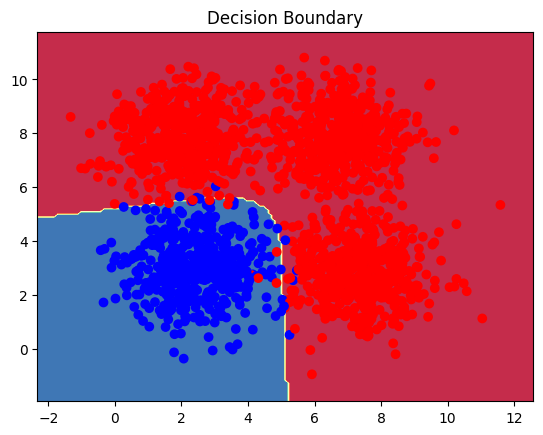

In [75]:
# parameters_2 = nn_model(X_2, Y_2, n_h=1, num_iterations=3000, learning_rate=1.2, print_cost=False)
parameters_2 = nn_model(X_2, Y_2, n_h=2, num_iterations=3000, learning_rate=1.2, print_cost=False)
# parameters_2 = nn_model(X_2, Y_2, n_h=15, num_iterations=3000, learning_rate=1.2, print_cost=False)

# This function will call predict function 
plot_decision_boundary(predict, parameters_2, X_2, Y_2)
plt.title("Decision Boundary")

You can see that there are some misclassified points - real-world datasets are usually linearly inseparable, and there will be a small percentage of errors. More than that, you do not want to build a model that fits too closely, almost exactly to a particular set of data - it may fail to predict future observations. This problem is known as **overfitting**.

Congrats on finishing this programming assignment!